# AUROC Evaluation and Visualization
This notebook loads the local uncertainty_measures.pkl & lgu_measures.pkl file and calculates the AUROC metric.

In [ ]:
import pickle
import numpy as np
import pandas as pd
import os

# Function to calculate AUROC
def auroc(y_true, y_score):
    from sklearn.metrics import roc_auc_score
    return roc_auc_score(y_true, y_score)

def accuracy_at_quantile(accuracies, uncertainties, quantile):
    cutoff = np.quantile(uncertainties, quantile)
    select = uncertainties <= cutoff
    return np.mean(accuracies[select])

# Function to calculate AUAC
def area_under_thresholded_accuracy(accuracies, uncertainties):
    quantiles = np.linspace(0.1, 1, 20)
    select_accuracies = np.array([accuracy_at_quantile(accuracies, uncertainties, q) for q in quantiles])
    dx = quantiles[1] - quantiles[0]
    area = (select_accuracies * dx).sum()
    return area

# Function to calculate ECE
def expected_calibration_error(y_true, y_prob, n_bins=10):
    '''
    y_true: True labels (0/1)
    y_prob: Confidence (smaller means more uncertain)
    n_bins: Number of bins
    '''
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        if np.any(bin_mask):
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(y_true)
    return ece

# Set result file paths
model_name_list = ['Llama-2-7b-chat', 'falcon-7b-instruct', 'falcon-7b', 'Mistral-7B-v0.1', 'Llama-2-13b-chat', 'Qwen3-32B']# 
dataset_list = ['trivia_qa', 'squad',  'bioasq',  'nq'] # 'hotpot_qa',
main_methods = ['semantic_entropy', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'mean_token_entropy', 'maximum_sequence_probability', 'perplexity', 'full_klu_heat_t=0.3_alpha_0.5', 'weighted_heat_t=0.3_kernel_entropy', 'avg_neg_logp', 'max_neg_logp'] #, 'avg_entropy', 'max_entropy'
main_names = ['SE', 'DSE', 'NE', 'p(True)', 'ER', 'MTE', 'MSP', 'PPL', 'KLE(full)', 'KLE(heat)', 'Avg Neg LogP', 'Max Neg LogP'] #, 'Avg Token Entropy', 'Max Token Entropy'

lge_methods = ['discrete_root_entropy', 'discrete_ige', 'discrete_lgu_edges_density', 'discrete_lgu_edges_density_weighted', 'discrete_lgu_avg_degree', 'discrete_lgu_estrada',
                'root_entropy', 'ige', 'lgu_edges_density', 'lgu_edges_density_weighted', 'lgu_avg_degree', 'lgu_estrada']
lge_names = ['DRE', 'DIGE', 'DLGU', 'DLGUWD', 'DLGUAD', 'DLGUE',
              'RE', 'IGE', 'LGU', 'LGUWD', 'LGUAD', 'LGUE']


df_auroc = pd.DataFrame(columns=['Model', 'Dataset', 'Method', 'AUROC', 'Logical Question Answer Rate'])
df_auarc = pd.DataFrame(columns=['Model', 'Dataset', 'Method', 'AUARC', 'Logical Question Answer Rate'])
df_ece = pd.DataFrame(columns=['Model', 'Dataset', 'Method', 'ECE', 'Logical Question Answer Rate'])
for model_name in model_name_list:
    for dataset_name in dataset_list:
        result_dir = f'/root/lmh/LGU/result/10_answer/{model_name}_{dataset_name}/files/'
        unc_meas_path = os.path.join(result_dir, 'uncertainty_measures.pkl')

        with open(unc_meas_path, 'rb') as f:
            results = pickle.load(f)

        # Set result file path
        lge_path = os.path.join(result_dir, 'lgu_measures.pkl')

        with open(lge_path, 'rb') as f:
            lgu_results = pickle.load(f)

        # Iterate all uncertainty_measures, calculate AUROC, AUAC, and ECE for each measure
        auroc_results = {}
        auarc_results = {}
        ece_results = {}
        print(f"Model: {model_name}, Dataset: {dataset_name}")
        y_true = results['validation_is_false']
        logical_question_number = lgu_results['logical_question_number']
        logical_question_rate = logical_question_number / len(y_true)

        for measure_name, measure_values in zip(main_names, [results['uncertainty_measures'][m] for m in main_methods]):
            # Truncate length in case measure_values is longer than y_true
            if len(measure_values) > len(y_true):
                measure_values = measure_values[:len(y_true)]
            try:
                # Calculate AUROC
                value_auroc = auroc(y_true, measure_values)
                df_auroc.loc[len(df_auroc)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'AUROC': value_auroc, 
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                # Calculate AUAC
                validation_accuracy = 1 - np.array(y_true)
                value_auac = area_under_thresholded_accuracy(validation_accuracy, measure_values)
                df_auarc.loc[len(df_auarc)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'AUARC': value_auac,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                # Calculate ECE, normalize first
                norm_measure_values = (np.array(measure_values) - np.min(measure_values)) / (np.max(measure_values) - np.min(measure_values) + 1e-8)
                value_ece = expected_calibration_error(np.int8(y_true), norm_measure_values)
                df_ece.loc[len(df_ece)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'ECE': value_ece,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                auroc_results[measure_name] = value_auroc
                auarc_results[measure_name] = value_auac
                ece_results[measure_name] = value_ece
                print(f"{measure_name}: AUROC = {value_auroc:.4f}, AUARC = {value_auac:.4f}, ECE = {value_ece:.4f}")
            except Exception as e:
                print(f"{measure_name}: Calculation failed, reason: {e}")

        # Iterate all LGE methods, calculate AUROC, AUAC, and ECE for each measure
        for measure_name, measure_values in zip(lge_names, [lgu_results['uncertainty_measures'][m] for m in lge_methods]):
            # Truncate length in case measure_values is longer than y_true
            if len(measure_values) > len(y_true):
                measure_values = measure_values[:len(y_true)]
            try:
                # Calculate AUROC
                value_auroc = auroc(y_true, measure_values)
                df_auroc.loc[len(df_auroc)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'AUROC': value_auroc,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                # Calculate AUAC
                validation_accuracy = 1 - np.array(y_true)
                value_auac = area_under_thresholded_accuracy(validation_accuracy, measure_values)
                df_auarc.loc[len(df_auarc)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'AUARC': value_auac,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                # Calculate ECE, normalize first
                norm_measure_values = (np.array(measure_values) - np.min(measure_values)) / (np.max(measure_values) - np.min(measure_values) + 1e-8)
                value_ece = expected_calibration_error(np.int8(y_true), norm_measure_values)
                df_ece.loc[len(df_ece)] = {
                        'Model': model_name,
                        'Dataset': dataset_name,
                        'Method': measure_name,
                        'ECE': value_ece,
                        'Logical Question Answer Rate': logical_question_rate
                    }
                
                auroc_results[measure_name] = value_auroc
                auarc_results[measure_name] = value_auac
                ece_results[measure_name] = value_ece
                print(f"{measure_name}: AUROC = {value_auroc:.4f}, AUARC = {value_auac:.4f}, ECE = {value_ece:.4f}")
            except Exception as e:
                print(f"{measure_name}: Calculation failed, reason: {e}")

# # Optional: save results as dictionary
# display({'AUROC': auroc_results, 'AUARC': auarc_results, 'ECE': ece_results})

模型: Llama-2-7b-chat, 数据集: trivia_qa
SE: AUROC = 0.8384, AUARC = 0.8322, ECE = 0.1197
DSE: AUROC = 0.8400, AUARC = 0.8296, ECE = 0.0913
NE: AUROC = 0.8059, AUARC = 0.8250, ECE = 0.1205
p(True): AUROC = 0.7506, AUARC = 0.8035, ECE = 0.2082
ER: AUROC = 0.6528, AUARC = 0.7442, ECE = 0.2313
MTE: AUROC = 0.5914, AUARC = 0.7121, ECE = 0.2541
MSP: AUROC = 0.5893, AUARC = 0.7118, ECE = 0.2662
PPL: AUROC = 0.5901, AUARC = 0.7118, ECE = 0.2792
KLE(full): AUROC = 0.8449, AUARC = 0.8326, ECE = 0.0628
KLE(heat): AUROC = 0.8473, AUARC = 0.8344, ECE = 0.0808
Avg Neg LogP: AUROC = 0.5901, AUARC = 0.7118, ECE = 0.2760
Max Neg LogP: AUROC = 0.5894, AUARC = 0.7118, ECE = 0.2617
DRE: AUROC = 0.8454, AUARC = 0.8316, ECE = 0.1100
DIGE: AUROC = 0.8403, AUARC = 0.8298, ECE = 0.1132
DLGU: AUROC = 0.8440, AUARC = 0.8307, ECE = 0.1215
DLGUWD: AUROC = 0.8452, AUARC = 0.8321, ECE = 0.1217
DLGUAD: AUROC = 0.8443, AUARC = 0.8304, ECE = 0.2047
DLGUE: AUROC = 0.8431, AUARC = 0.8304, ECE = 0.2785
RE: AUROC = 0.8459, AUA

In [2]:
df_auroc.to_csv('/root/lmh/LGU/result/10_answer/auroc_results.csv', index=False)
df_auarc.to_csv('/root/lmh/LGU/result/10_answer/auarc_results.csv', index=False)
df_ece.to_csv('/root/lmh/LGU/result/10_answer/ece_results.csv', index=False)

# Logical Data Distribution

In [ ]:
for model in model_name_list:
    for dataset in dataset_list:
        df_auroc_subset = df_auroc[(df_auroc['Model'] == model) & (df_auroc['Dataset'] == dataset)]
        print(f"Model: {model}, Dataset: {dataset}")
        logical_rate = df_auroc_subset['Logical Question Answer Rate'].values[0]
        print(f"Logical Question Answer Rate: {logical_rate:.4f}")


模型: Llama-2-7b-chat, 数据集: trivia_qa
Logical Question Answer Rate: 0.4825
模型: Llama-2-7b-chat, 数据集: squad
Logical Question Answer Rate: 0.8900
模型: Llama-2-7b-chat, 数据集: bioasq
Logical Question Answer Rate: 0.7725
模型: Llama-2-7b-chat, 数据集: nq
Logical Question Answer Rate: 0.7725
模型: falcon-7b-instruct, 数据集: trivia_qa
Logical Question Answer Rate: 0.9025
模型: falcon-7b-instruct, 数据集: squad
Logical Question Answer Rate: 0.9900
模型: falcon-7b-instruct, 数据集: bioasq
Logical Question Answer Rate: 0.9650
模型: falcon-7b-instruct, 数据集: nq
Logical Question Answer Rate: 0.9875
模型: falcon-7b, 数据集: trivia_qa
Logical Question Answer Rate: 0.8725
模型: falcon-7b, 数据集: squad
Logical Question Answer Rate: 0.9925
模型: falcon-7b, 数据集: bioasq
Logical Question Answer Rate: 0.9600
模型: falcon-7b, 数据集: nq
Logical Question Answer Rate: 0.9850
模型: Mistral-7B-v0.1, 数据集: trivia_qa
Logical Question Answer Rate: 0.7500
模型: Mistral-7B-v0.1, 数据集: squad
Logical Question Answer Rate: 0.9800
模型: Mistral-7B-v0.1, 数据集: bioasq
Log

# Paint

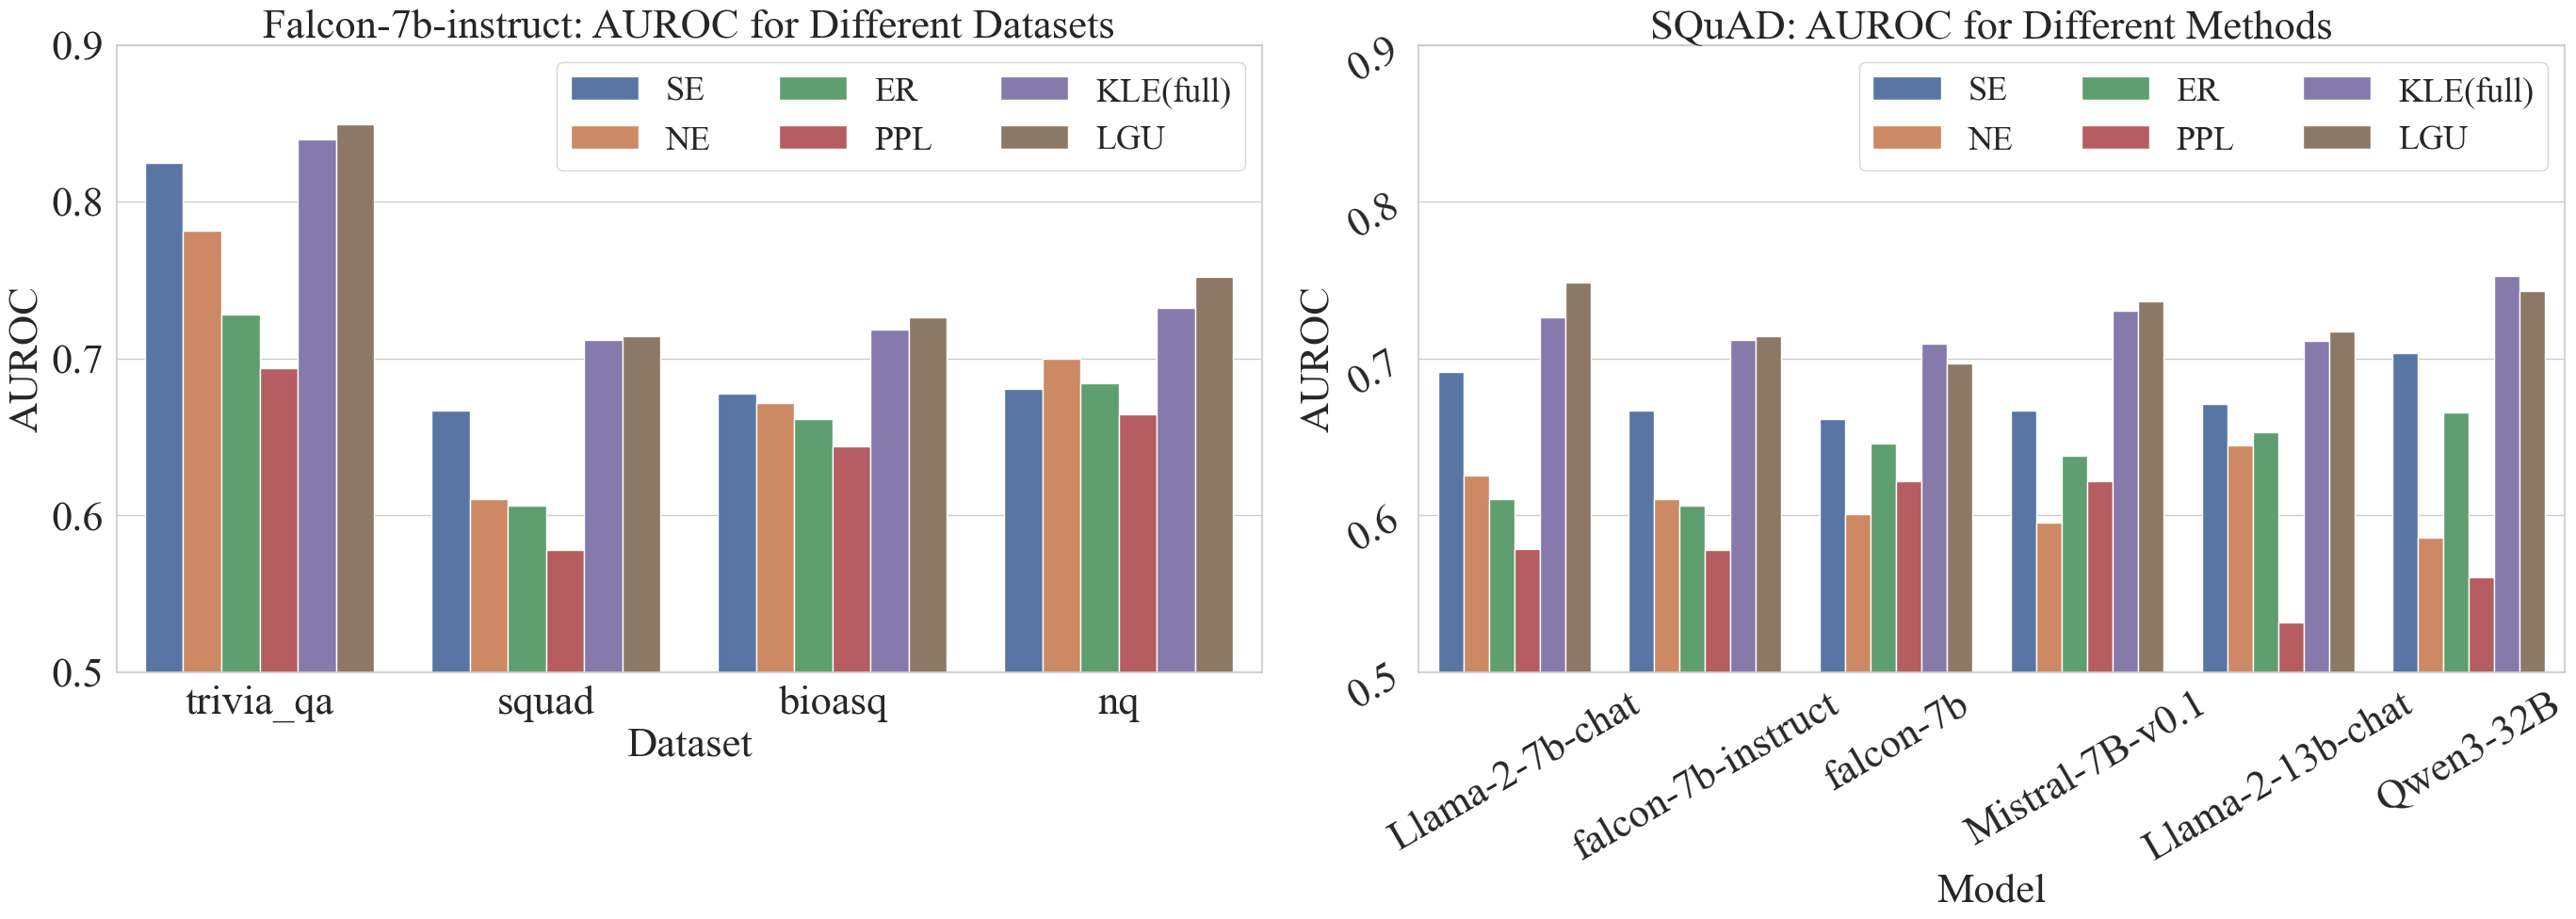

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 36
})
sns.set_theme(style="whitegrid", font="Times New Roman", font_scale=1.2)

methods_to_plot = ['LGU', 'SE', 'KLE(full)', 'PPL', 'ER', 'NE']
# methods_to_plot = ['Discrete Semantic Entropy', 'KLE(heat)', 'Discrete Logical Graph Entropy']
df_filtered = df_auroc[df_auroc['Method'].isin(methods_to_plot)]

# Select a model and a dataset
model_to_plot = "falcon-7b-instruct"
dataset_to_plot = "squad"
df_model = df_filtered[df_filtered["Model"] == model_to_plot]
df_dataset = df_filtered[df_filtered["Dataset"] == dataset_to_plot]

fig, axes = plt.subplots(1, 2, figsize=(28, 10))  # Adjust subplot size, width=28, height=10

model_to_plot = "Falcon-7b-instruct"
dataset_to_plot = "SQuAD"


# Subplot 1: AUROC for different datasets of the same model
bar1 = sns.barplot(
    data=df_model,
    x="Dataset",
    y="AUROC",
    hue="Method",
    ax=axes[0]
),
axes[0].set_title(f"{model_to_plot}: AUROC for Different Datasets", fontsize=32)
axes[0].set_ylabel("AUROC", fontsize=32)
axes[0].set_xlabel("Dataset", fontsize=32)
axes[0].set_ylim(0.5, 0.9)  # Set y-axis range
axes[0].legend(loc="best", ncol=3, fontsize=26)
axes[0].tick_params(axis='both', labelsize=32)  # Increase axis label font size

# Annotate each bar with its value
# for p in bar1.patches:
#     height = p.get_height()
#     if not np.isnan(height):
#         bar1.annotate(f'{height:.3f}', 
                    #    (p.get_x() + p.get_width() / 2., height), 
                    #    ha='center', va='bottom', fontsize=6, color='black', rotation=0)

# Subplot 2: AUROC for different methods on the same dataset
bar2 = sns.barplot(
    data=df_dataset,
    x="Model",
    y="AUROC",
    hue="Method",
    ax=axes[1]
),
axes[1].set_title(f"{dataset_to_plot}: AUROC for Different Methods", fontsize=32)
axes[1].set_ylabel("AUROC", fontsize=32)
axes[1].set_xlabel("Model", fontsize=32)
axes[1].set_ylim(0.5, 0.9)  # Set y-axis range
axes[1].tick_params(axis='both', rotation=30, labelsize=32)
axes[1].legend(loc="best", ncol=3, fontsize=26)
# for p in bar2.patches:
#     height = p.get_height()
#     if not np.isnan(height):
#         bar2.annotate(f'{height:.3f}', 
                    #    (p.get_x() + p.get_width() / 2., height), 
                    #    ha='center', va='bottom', fontsize=6, color='black', rotation=0)

plt.tight_layout()
plt.savefig('wb_auroc.pdf')  # Save figure
plt.show()

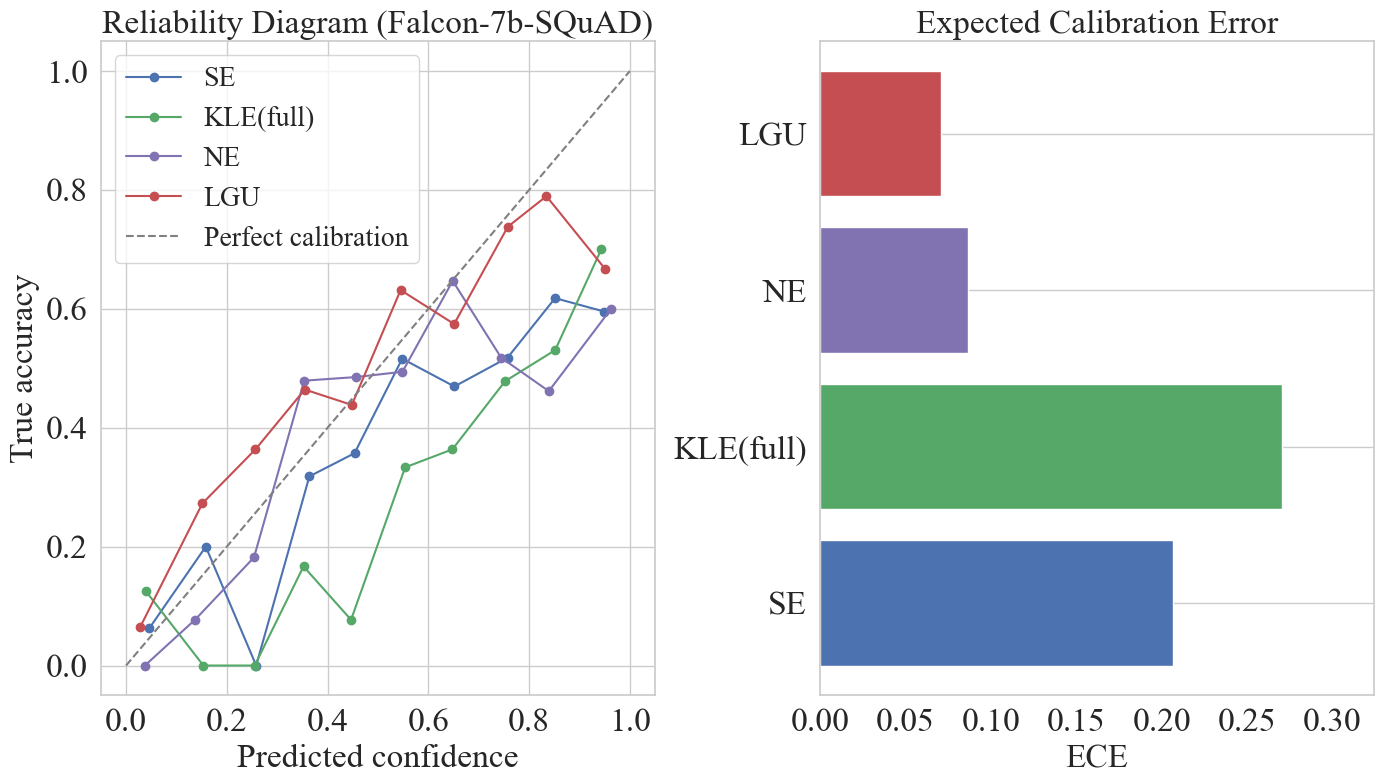

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import numpy as np
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
sns.set_theme(style="whitegrid", font="Times New Roman")

# Method and color mapping (keep left and right plots consistent)
main_methods = ['semantic_entropy', 'full_klu_heat_t=0.3_alpha_0.5', 'regular_entropy','lgu_edges_density']
main_names = ['SE', 'KLE(full)', 'NE', 'LGU']
color_map = {
    'SE': '#4C72B0',
    'LGU': '#C44E52',
    'KLE(full)': '#55A868',
    'NE': '#8172B2'
}

result_dir = f'/root/lmh/LGU/result/10_answer/falcon-7b_squad/files/'
unc_meas_path = os.path.join(result_dir, 'uncertainty_measures.pkl')

with open(unc_meas_path, 'rb') as f:
    results = pickle.load(f)

# Set result file path
lge_path = os.path.join(result_dir, 'lgu_measures.pkl')

with open(lge_path, 'rb') as f:
    lgu_results = pickle.load(f)

# Ensure y_true is numpy array
y_true = results['validation_is_false']
y_true = np.asarray(y_true).astype(int)

plt.figure(figsize=(14, 8))

# Left plot (reliability diagram)
plt.subplot(1, 2, 1)
for method, name in zip(main_methods, main_names):
    if method.startswith('lgu'):
        probs = np.array(lgu_results['uncertainty_measures'][method])
    else:
        probs = np.array(results['uncertainty_measures'][method])

    # Ensure same length
    L = min(len(probs), len(y_true))
    probs = probs[:L]
    y_true_cut = y_true[:L]

    # Normalize to [0,1]
    probs = (probs - np.min(probs)) / (np.max(probs) - np.min(probs) + 1e-8)

    fraction_of_positives, mean_predicted_value = calibration_curve(y_true_cut, probs, n_bins=10)
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name, color=color_map[name])

plt.plot([0,1], [0,1], "--", color='gray', label="Perfect calibration")
plt.xlabel("Predicted confidence", fontsize=24)
plt.ylabel("True accuracy", fontsize=24)
plt.title("Reliability Diagram (Falcon-7b-SQuAD)", fontsize=24)
plt.legend(fontsize=20)
plt.grid(True)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Right plot (ECE bar chart)
plt.subplot(1, 2, 2)
ece_values = []
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)

for method, name in zip(main_methods, main_names):
    if method.startswith('lgu'):
        probs = np.array(lgu_results['uncertainty_measures'][method])
    else:
        probs = np.array(results['uncertainty_measures'][method])

    L = min(len(probs), len(y_true))
    probs = probs[:L]
    y_true_cut = y_true[:L]

    probs = (probs - np.min(probs)) / (np.max(probs) - np.min(probs) + 1e-8)

    binids = np.digitize(probs, bins) - 1
    binids = np.clip(binids, 0, n_bins - 1)  # Prevent -1 or n_bins
    
    ece = 0.0
    for i in range(n_bins):
        bin_mask = (binids == i)
        if np.any(bin_mask):
            bin_acc = np.mean(y_true_cut[bin_mask])
            bin_conf = np.mean(probs[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(y_true_cut)
    ece_values.append(ece)

# Set colors by method order and plot
bar_colors = [color_map[name] for name in main_names]
bars = plt.barh(main_names, ece_values, color=bar_colors)
# for i, v in enumerate(ece_values):
#     plt.text(v + 0.01 * max(0.01, max(ece_values)), i, f"{v:.3f}", va='center', fontsize=12)

plt.xlabel("ECE", fontsize=24)
plt.title("Expected Calibration Error", fontsize=24)
plt.xlim(0, max(ece_values) * 1.2 if len(ece_values) and max(ece_values) > 0 else 1.0)
plt.grid(axis='x')
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

plt.tight_layout()
plt.savefig('falcon-7b-squad_reliability_ece.pdf')  # Save figure
plt.show()

相关性系数（numpy）: 0.5722
皮尔逊相关系数: 0.5722, p值: 0.003479


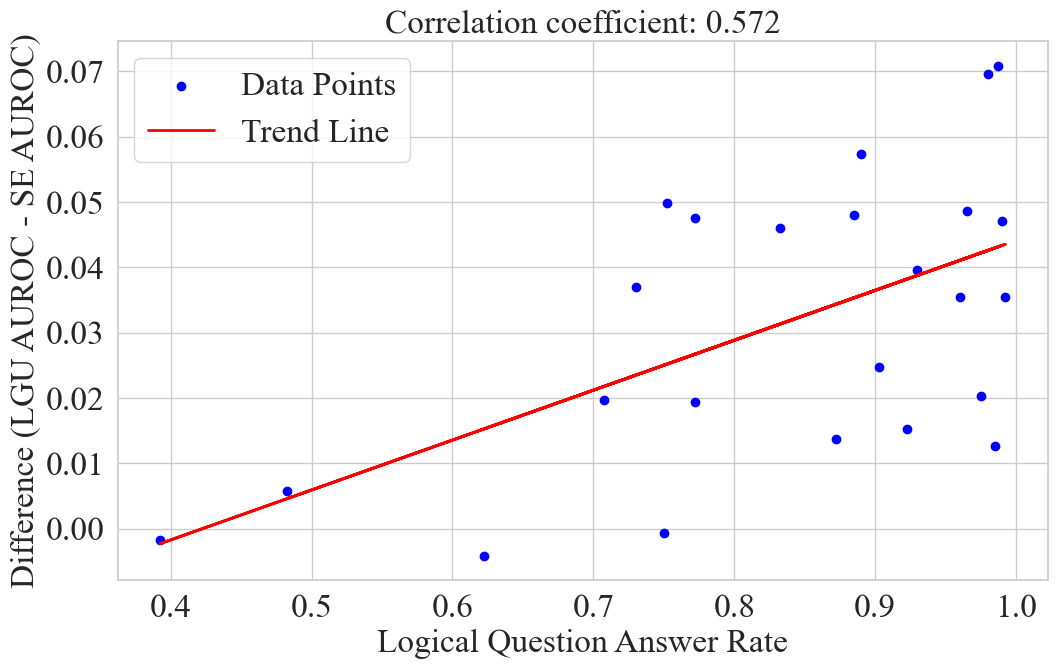

In [ ]:
from scipy.stats import pearsonr

differences_se_lge = []
logical_question_rates = []

for model_name in model_name_list:
    for dataset_name in dataset_list:
        df_temp = df_auroc[(df_auroc['Model'] == model_name) & (df_auroc['Dataset'] == dataset_name)]
        difference_se_lge = df_temp[df_temp['Method'] == 'LGU']['AUROC'].values[0] - df_temp[df_temp['Method'] == 'SE']['AUROC'].values[0]
        logical_question_rate = df_temp['Logical Question Answer Rate'].values[0]
        differences_se_lge.append(difference_se_lge)
        logical_question_rates.append(logical_question_rate)

# Calculate correlation coefficient
corr_coef = np.corrcoef(differences_se_lge, logical_question_rates)[0, 1]
pearson_r, p_value = pearsonr(differences_se_lge, logical_question_rates)
print(f"Correlation coefficient (numpy): {corr_coef:.4f}")
print(f"Pearson correlation coefficient: {pearson_r:.4f}, p-value: {p_value:.4g}")

# Plot scatter and trend line
plt.figure(figsize=(12, 7))
plt.scatter(logical_question_rates, differences_se_lge, color='blue', label='Data Points')

# Linear fit
fit = np.polyfit(logical_question_rates, differences_se_lge, 1)
fit_fn = np.poly1d(fit)
plt.plot(logical_question_rates, fit_fn(logical_question_rates), color='red', linewidth=2, label='Trend Line')

plt.xlabel('Logical Question Answer Rate', fontsize=24)
plt.ylabel('Difference (LGU AUROC - SE AUROC)', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.title(f'Correlation coefficient: {pearson_r:.3f}', fontsize=24)
plt.grid(True)
plt.legend(fontsize=24)
plt.savefig('lgu_se_correlation.pdf')  # Save figure
plt.show()